## Logistic Regression

This will be used as our baseline model.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset (adjust the filename/path as needed)
df = pd.read_csv("../data/combined_synthetic_data_with_bounds.csv")

In [2]:
from imblearn.under_sampling import RandomUnderSampler


In [3]:


# Define features
features = [
    'Day',              # Categorical (e.g., "Wednesday")
    'Station Name',     # Categorical (e.g., "VICTORIA PARK STATION")
    'Line Number',      # Categorical (e.g., "LINE 2")
    'Bound',            # Categorical (e.g., "W")
    'Is Rush Hour',     # Boolean flag (converted to 0/1)
    'Is Terminal Station',  # Boolean flag (converted to 0/1)
    'Ridership'         ,# Numeric (passenger counts)
    'Hour',
    'Minute',
    'Month'
]

X = df[features]
y = df['Delayed']

# Convert Boolean flags to integers, if necessary
X['Is Rush Hour'] = X['Is Rush Hour'].astype(int)
X['Is Terminal Station'] = X['Is Terminal Station'].astype(int)

# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rus = RandomUnderSampler(sampling_strategy={0: y_train.value_counts()[1] * 100}, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

# Identify categorical and numeric features
categorical_features = ['Day', 'Station Name', 'Line Number', 'Bound']
numeric_features = ['Ridership', 'Is Rush Hour', 'Is Terminal Station', 'Hour', 'Minute', 'Month']

# Build a preprocessing pipeline:
# - OneHotEncoder for categorical features (ignoring unknown categories)
# - StandardScaler for numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

# Create the logistic regression pipeline with class_weight adjustment.
# Setting class_weight='balanced' adjusts weights inversely proportional to class frequencies.
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])



# Train the model.
model.fit(X_train_res, y_train_res)

# Make predictions on the test set.
y_pred = model.predict(X_test)

# Evaluate the model.
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))




C:\Users\owner\AppData\Local\Temp\ipykernel_30980\1266846758.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Is Rush Hour'] = X['Is Rush Hour'].astype(int)
C:\Users\owner\AppData\Local\Temp\ipykernel_30980\1266846758.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Is Terminal Station'] = X['Is Terminal Station'].astype(int)


Accuracy: 0.6907890705389187
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.69      0.82   4074732
           1       0.00      0.58      0.00      5030

    accuracy                           0.69   4079762
   macro avg       0.50      0.64      0.41   4079762
weighted avg       1.00      0.69      0.82   4079762



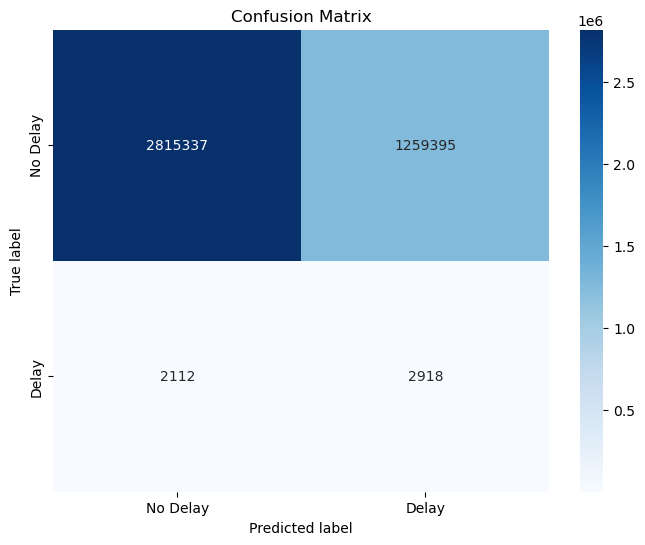

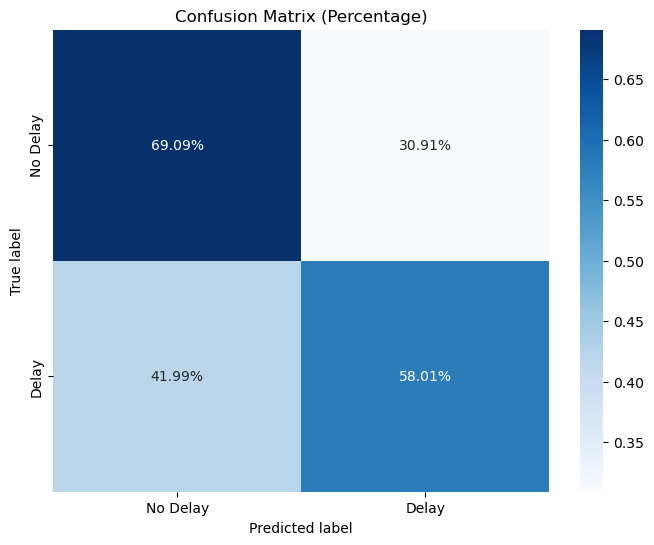

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Delay', 'Delay'], yticklabels=['No Delay', 'Delay'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()


# Confusion matrix based on percentage of records
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt='.2%', cmap='Blues', xticklabels=['No Delay', 'Delay'], yticklabels=['No Delay', 'Delay'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix (Percentage)')
plt.show()